# Image Caption Generator

Build a deep learning model that generates a textual caption for an input image.

**Architecture (assignment spec).** A **CNN encoder** produces a suitable embedding of the image; this embedding is passed to an **RNN decoder** that generates the caption text word by word.

- **Encoder:** pre-trained CNN (InceptionV3, ImageNet weights) used as a fixed feature extractor.
- **Decoder:** RNN (LSTM) with word embeddings, trained to predict the next word given the image features and the words so far.
- **Dataset:** [Flickr30k](https://www.kaggle.com/datasets/hsankesara/flickr-image-dataset) — ~31k images, each with 5 human captions.
- **Metric:** BLEU score on a held-out test split.

Framework: **TensorFlow / Keras**.

## 1. Dataset

The Flickr30k dataset (~5 GB of JPGs) is **not committed** to the repo (see `.gitignore`).
Source: <https://www.kaggle.com/datasets/hsankesara/flickr-image-dataset>

Expected layout in the project:

```
datasets/flickr30k_images/
├── 1000092795.jpg        # ~31k .jpg files, directly here
├── ...
└── results.csv           # captions, '|'-separated (also mirrored in datasets/results.csv)
```

`results.csv` columns: `image_name | comment_number | comment` (5 comments per image).

In [91]:
# IMPORTANT: Keras 3 (default in TF 2.21) has an unusably slow LSTM on CPU
# (a single train step can hang for minutes). Force the legacy Keras 2 backend
# (tf-keras), which has a fast CPU RNN implementation. This env var MUST be set
# before importing tensorflow. Requires a kernel restart to take effect.
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

# IMPORTANT: import tensorflow BEFORE pandas. pandas pulls in pyarrow's native
# runtime, and if that loads first, every TF *training* step deadlocks on this
# machine (macOS ARM, CPU-only): forward pass works, train_on_batch/fit hang
# forever. Verified A/B with identical code — only the import order differed.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.applications.inception_v3 import preprocess_input
# NOTE: never import from plain `keras` here (e.g. `from keras.models import
# Model`) — that is Keras 3, which silently replaces the legacy backend and
# brings back the slow-LSTM bug.

import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict, Counter

import tf_keras
print("TensorFlow:", tf.__version__)
print("Keras backend:", tf_keras.__version__, "(expect 2.x -> legacy, fast CPU LSTM)")
print("GPU:", tf.config.list_physical_devices('GPU'))
assert keras.Model is tf_keras.Model, "tf.keras is NOT the legacy backend — restart the kernel and run this cell FIRST"

TensorFlow: 2.21.0
Keras backend: 2.21.0 (expect 2.x -> legacy, fast CPU LSTM)
GPU: []


In [92]:
# Resolve dataset paths (notebook runs from notebooks/, dataset lives in ../datasets)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "datasets" / "flickr30k_images"

# Images sit directly in DATA_DIR; captions in results.csv (here or one level up).
IMAGES_DIR = DATA_DIR
CAPTIONS_FILE = DATA_DIR / "results.csv"
if not CAPTIONS_FILE.exists():
    CAPTIONS_FILE = PROJECT_ROOT / "datasets" / "results.csv"

assert DATA_DIR.exists(), f"Dataset folder not found: {DATA_DIR}\nDownload it first (see cell above)."
assert CAPTIONS_FILE.exists(), f"Captions file not found: {CAPTIONS_FILE}"
assert IMAGES_DIR.exists(), f"Images folder not found: {IMAGES_DIR}"

n_images = len(list(IMAGES_DIR.glob('*.jpg')))
print("Images dir   :", IMAGES_DIR)
print("Captions file:", CAPTIONS_FILE)
print("# .jpg files :", n_images)

Images dir   : /Users/simonenegro/Documents/MAGISTRALE/ML and DL/datasets/flickr30k_images
Captions file: /Users/simonenegro/Documents/MAGISTRALE/ML and DL/datasets/flickr30k_images/results.csv
# .jpg files : 31783


## 2. Load and inspect the captions

In [93]:
# results.csv is '|'-separated and its header has stray spaces in the column names.
captions = pd.read_csv(CAPTIONS_FILE, sep='|')
captions.columns = [c.strip() for c in captions.columns]  # -> image_name, comment_number, comment
captions = captions.rename(columns={'comment': 'caption'})

# Strip whitespace, drop malformed rows (a few rows in this dataset are mis-delimited).
captions['image_name'] = captions['image_name'].astype(str).str.strip()
captions['caption'] = captions['caption'].astype(str).str.strip()
captions = captions[captions['caption'].str.len() > 0].reset_index(drop=True)

print("Shape:", captions.shape)
print("Unique images:", captions['image_name'].nunique())
print("Avg captions per image:", round(len(captions) / captions['image_name'].nunique(), 2))
captions.head()

Shape: (158914, 3)
Unique images: 31783
Avg captions per image: 5.0


,image_name,comment_number,caption
0,1000092795.jpg,0,Two young guys with shaggy hair look at their ...
1,1000092795.jpg,1,"Two young , White males are outside near many ..."
2,1000092795.jpg,2,Two men in green shirts are standing in a yard .
3,1000092795.jpg,3,A man in a blue shirt standing in a garden .
4,1000092795.jpg,4,Two friends enjoy time spent together .


count    158914.000000
mean         13.389418
std           5.421043
min           2.000000
25%          10.000000
50%          12.000000
75%          16.000000
max          82.000000
Name: n_words, dtype: float64


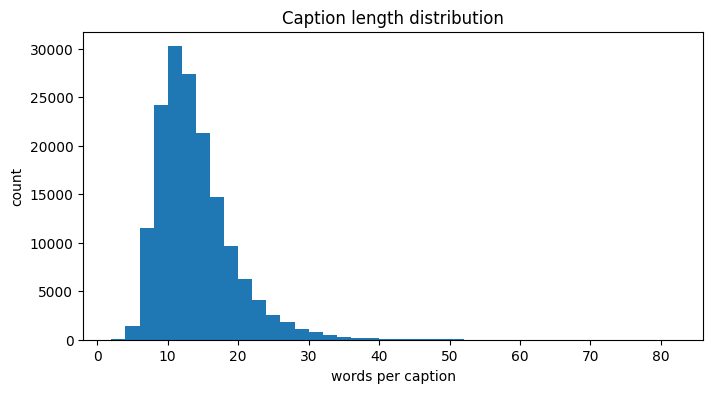

In [94]:
# Caption length distribution (in words) — informs the max sequence length later.
captions['n_words'] = captions['caption'].str.split().apply(len)
print(captions['n_words'].describe())

plt.figure(figsize=(8, 4))
plt.hist(captions['n_words'], bins=40)
plt.xlabel('words per caption')
plt.ylabel('count')
plt.title('Caption length distribution')
plt.show()

## 3. Sanity check — show an image with its captions

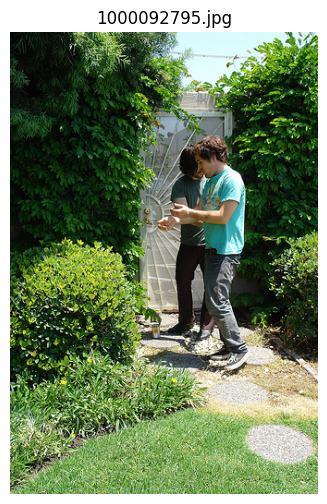

Captions:
  1. Two young guys with shaggy hair look at their hands while hanging out in the yard .
  2. Two young , White males are outside near many bushes .
  3. Two men in green shirts are standing in a yard .
  4. A man in a blue shirt standing in a garden .
  5. Two friends enjoy time spent together .


In [95]:
sample_name = captions['image_name'].iloc[0]
sample_caps = captions[captions['image_name'] == sample_name]['caption'].tolist()

img = keras.utils.load_img(IMAGES_DIR / sample_name)
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title(sample_name)
plt.show()

print("Captions:")
for i, c in enumerate(sample_caps, 1):
    print(f"  {i}. {c}")

---
**Next steps** (upcoming cells):
1. Text preprocessing — clean, lowercase, add `<start>`/`<end>` tokens, build vocabulary.
2. Encoder — extract InceptionV3 features for every image (cache to disk).
3. Decoder — LSTM language model conditioned on image features.
4. Training loop + teacher forcing.
5. Inference (greedy / beam search) and BLEU evaluation.

In [96]:
captions['seq'] = "startseq " + captions['caption'].str.lower().str.replace(
    r"[^a-z ]", " ", regex=True).str.replace(
    r"\s+", " ", regex=True).str.strip() + " endseq"

print(captions['seq'].head())

0    startseq two young guys with shaggy hair look ...
1    startseq two young white males are outside nea...
2    startseq two men in green shirts are standing ...
3    startseq a man in a blue shirt standing in a g...
4    startseq two friends enjoy time spent together...
Name: seq, dtype: str


In [97]:
img2caps = defaultdict(list)
for name, seq in zip(captions['image_name'], captions['seq']):
    img2caps[name].append(seq)

for k in list(img2caps)[:2]:
    print(k, img2caps[k])


1000092795.jpg ['startseq two young guys with shaggy hair look at their hands while hanging out in the yard endseq', 'startseq two young white males are outside near many bushes endseq', 'startseq two men in green shirts are standing in a yard endseq', 'startseq a man in a blue shirt standing in a garden endseq', 'startseq two friends enjoy time spent together endseq']
10002456.jpg ['startseq several men in hard hats are operating a giant pulley system endseq', 'startseq workers look down from up above on a piece of equipment endseq', 'startseq two men working on a machine wearing hard hats endseq', 'startseq four men on top of a tall structure endseq', 'startseq three men on a large rig endseq']


In [98]:
all_images = list(img2caps.keys())
random.seed(42)
random.shuffle(all_images)

n = len(all_images)
c1 = int(n * 0.1)   # first 10% -> test
c2 = int(n * 0.2)   # next 10% -> val, rest -> train

test_imgs = set(all_images[:c1])
val_imgs = set(all_images[c1:c2])
train_imgs = set(all_images[c2:])

print(f"train={len(train_imgs)}  val={len(val_imgs)}  test={len(test_imgs)}")

train=25427  val=3178  test=3178


In [99]:
counter = Counter()

MIN_FREQ = 3
max_length = 0

for name in train_imgs:
    for seq in img2caps[name]:
        counter.update(seq.split())
        if max_length < len(seq.split()):
            max_length = len(seq.split())

word2idx = {"<pad>": 0, "<unk>": 1}

for word, count in counter.items():
    if count >= MIN_FREQ:
        word2idx.setdefault(word, len(word2idx))

idx2word = {v: k for k, v in word2idx.items()}

vocab_size = len(word2idx)

# Cap max_length: the true max (~80) is an outlier; padding every prefix to 80
# wastes compute and unrolls the LSTM 80 steps. 30 covers almost all captions.
max_length = min(max_length, 30)

print("vocab_size:", vocab_size, "max_length:", max_length)

vocab_size: 8927 max_length: 30


In [100]:
encoder = keras.applications.InceptionV3(weights='imagenet', include_top=False, pooling='avg')

def load_img_arr(path):
    img = keras.utils.load_img(path, target_size=(299, 299))
    arr = keras.utils.img_to_array(img)
    return preprocess_input(arr)

a = load_img_arr(IMAGES_DIR / next(iter(all_images)))
print(a.shape, a.min(), a.max())   # (299,299,3), valori ~[-1,1]

feat = encoder(a[None, ...], training=False).numpy()
print(feat.shape)


(299, 299, 3) -1.0 1.0
(1, 2048)


In [101]:
FEATURES_PATH = PROJECT_ROOT/"datasets"/"features.npy"

if os.path.exists(FEATURES_PATH):
    features = np.load(FEATURES_PATH, allow_pickle=True).item()
else:
    features = {}
    batch, names = [], []
    from tqdm.auto import tqdm
    for name in tqdm(all_images):
        batch.append(load_img_arr(IMAGES_DIR/name))
        names.append(name)
        if len(batch) == 64:
            feats = encoder(np.array(batch), training=False).numpy()
            for name, f in zip(names, feats): features[name] = f
            batch, names = [], []
    if batch:
        feats = encoder(np.array(batch), training=False).numpy()
        for name, f in zip(names, feats): features[name] = f
    np.save(FEATURES_PATH, features)


In [102]:
EMBED_DIM = 256
UNITS = 256

# Ramo immagine
img_input = Input(shape=(2048,), name="image")
fi1 = Dropout(0.6)(img_input)          # v2: 0.5 -> 0.6 (piu' regolarizzazione anti-overfit)
fi2 = Dense(UNITS, activation='relu')(fi1)

# Ramo sequenza
seq_input = Input(shape=(max_length,), name="sequence")
se1 = Embedding(vocab_size, EMBED_DIM, mask_zero=True)(seq_input)
se2 = Dropout(0.6)(se1)                 # v2: 0.5 -> 0.6
se3 = LSTM(UNITS)(se2)                  # NB: niente recurrent_dropout -> romperebbe LSTM veloce su CPU

# Merge + output (architettura invariata vs v1: add)
dec1 = layers.add([fi2, se3])
dec2 = Dense(UNITS, activation='relu')(dec1)
output = Dense(vocab_size, activation='softmax')(dec2)

# Modello completo: due input, un output
model = Model([img_input, seq_input], output)
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
model.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 sequence (InputLayer)       [(None, 30)]                 0         []                            
                                                                                                  
 image (InputLayer)          [(None, 2048)]               0         []                            
                                                                                                  
 embedding_3 (Embedding)     (None, 30, 256)              2285312   ['sequence[0][0]']            
                                                                                                  
 dropout_6 (Dropout)         (None, 2048)                 0         ['image[0][0]']               
                                                                                            

In [103]:
def data_generator(image_set, batch_size):
    imgs = list(image_set)
    while True:
        random.shuffle(imgs)
        X1, X2, y = [], [], []
        for name in imgs:
            feat = features[name]
            for seq in img2caps[name]:
                ids = [word2idx.get(w, 1) for w in seq.split()]
                for i in range(1, len(ids)):
                    in_seq = keras.utils.pad_sequences([ids[:i]], maxlen=max_length)[0]
                    X1.append(feat)
                    X2.append(in_seq)
                    y.append(ids[i])
                    if len(y) == batch_size:
                        yield (np.array(X1), np.array(X2)), np.array(y)
                        X1, X2, y = [], [], []

BATCH = 128
n_pairs = sum(len(seq.split()) - 1 for im in train_imgs for seq in img2caps[im])
steps = n_pairs // BATCH
print("pairs:", n_pairs, "steps/epoch:", steps)


pairs: 1690485 steps/epoch: 13206


In [104]:
# v2: salva su file NUOVO -> v1 (caption_model.keras) resta intatto per confronto.
ckpt = ModelCheckpoint(
    "caption_model_v2.keras", monitor='val_loss', save_best_only=True, verbose=1, mode='min')
# restore_best_weights=True -> il modello salvato e' SEMPRE il best-val (NON quello
# overfittato delle epoche dopo): l'anti-overfit e' gia' garantito da qui.
# patience 6 -> 8: con piu' dropout il modello converge piu' lento, dare piu' spazio.
early = EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True)

BATCH = 128
EPOCHS = 100          # tetto alto: early ferma a plateau, non ci arriva
# 2000 step/epoch (~256k coppie) + reshuffle del generator ogni epoch ->
# su piu' epoch il modello vede comunque tutto il dataset. ~4min/epoch.
steps_train = 2000
steps_val   = 100

history = model.fit(
    data_generator(train_imgs, BATCH), 
    steps_per_epoch=steps_train,
    validation_data=data_generator(val_imgs, BATCH), 
    validation_steps=steps_val,
    epochs=EPOCHS, 
    callbacks=[ckpt, early],
    verbose=1)

Epoch 1/100
2000/2000 [==============================] - ETA: 0s - loss: 4.6785
Epoch 1: val_loss improved from inf to 4.09245, saving model to caption_model_v2.keras
2000/2000 [==============================] - 138s 69ms/step - loss: 4.6785 - val_loss: 4.0924
Epoch 2/100
2000/2000 [==============================] - ETA: 0s - loss: 4.0354
Epoch 2: val_loss improved from 4.09245 to 3.81741, saving model to caption_model_v2.keras
2000/2000 [==============================] - 139s 69ms/step - loss: 4.0354 - val_loss: 3.8174
Epoch 3/100
2000/2000 [==============================] - ETA: 0s - loss: 3.8350
Epoch 3: val_loss improved from 3.81741 to 3.74030, saving model to caption_model_v2.keras
2000/2000 [==============================] - 141s 70ms/step - loss: 3.8350 - val_loss: 3.7403
Epoch 4/100
2000/2000 [==============================] - ETA: 0s - loss: 3.7507
Epoch 4: val_loss improved from 3.74030 to 3.65309, saving model to caption_model_v2.keras
2000/2000 [===========================

[2, 3, 29, 11, 3, 43, 33, 20, 91, 11, 54, 13, 3, 451, 16]
['startseq', 'a', 'man', 'in', 'a', 'blue', 'shirt', 'is', 'standing', 'in', 'front', 'of', 'a', 'building', 'endseq']


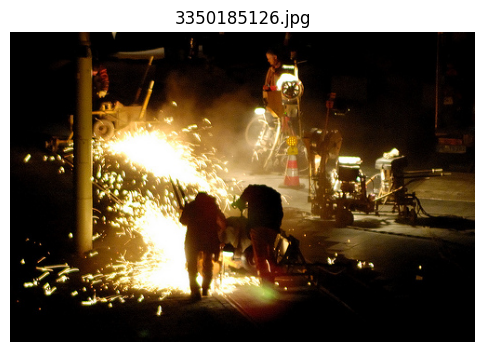

In [ ]:
def generate_caption(model, name):
    feat = features[name]
    ids = [word2idx['startseq']]

    for _ in range(max_length):
        seq = pad_sequences([ids], maxlen=max_length)
        yhat = model.predict([feat[None,:], seq], verbose=0)
        idx = int(np.argmax(yhat))
        ids.append(idx)
        if idx == word2idx['endseq']: break
    print(ids)
    print([idx2word[i] for i in ids])

random.seed(50)
name = random.choice(list(test_imgs))

generate_caption(model, name)

img = keras.utils.load_img(IMAGES_DIR / name)
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title(name)
plt.show()

## 6. Attention model (v3)

Il modello base (add / concat merge) inietta l'immagine **una sola volta** come
un unico vettore 2048 pooled: l'LSTM la "dimentica" e ricade sul prior
linguistico -> caption che non descrivono l'immagine.

**Attention (Show, Attend and Tell):** invece del vettore pooled si usano le
feature **spaziali** dell'encoder -> 64 regioni (8x8) x 2048. Ad ogni parola il
decoder pesa le 64 regioni in base allo stato dell'LSTM e costruisce un
*context* focalizzato sulla parte di immagine rilevante. Aggancio img->testo
molto piu' forte.

Vincolo hardware: le feature spaziali full-dataset sono ~16.7GB (non entrano in
16GB RAM), quindi si lavora su un **subset di 12000 immagini** (float16, ~3.2GB).

In [106]:
# Subset per l'attention (feature spaziali: full dataset non entra in 16GB RAM).
# sorted() perche' i set non hanno ordine deterministico.
random.seed(123)
att_train = random.sample(sorted(train_imgs), 10000)
att_val   = random.sample(sorted(val_imgs),    1000)
att_test  = random.sample(sorted(test_imgs),   1000)
att_all   = att_train + att_val + att_test
print(f"att subset -> train={len(att_train)}  val={len(att_val)}  test={len(att_test)}  total={len(att_all)}")

att subset -> train=10000  val=1000  test=1000  total=12000


In [107]:
# InceptionV3 SENZA pooling -> mappa spaziale (8,8,2048) -> 64 regioni x 2048.
# float16 per stare in RAM (~3.2GB per 12k img). Cache su disco.
SPATIAL_PATH = PROJECT_ROOT/"datasets"/"features_spatial.npy"

if os.path.exists(SPATIAL_PATH):
    features_sp = np.load(SPATIAL_PATH, allow_pickle=True).item()
    print("loaded", len(features_sp), "spatial features from cache")
else:
    from tqdm.auto import tqdm
    encoder_sp = keras.applications.InceptionV3(weights='imagenet', include_top=False, pooling=None)
    features_sp = {}
    batch, names = [], []
    def flush(batch, names):
        fm = encoder_sp(np.array(batch), training=False).numpy()        # (B,8,8,2048)
        fm = fm.reshape(fm.shape[0], -1, fm.shape[-1]).astype(np.float16) # (B,64,2048)
        for nm, f in zip(names, fm):
            features_sp[nm] = f
    for name in tqdm(att_all):
        batch.append(load_img_arr(IMAGES_DIR/name)); names.append(name)
        if len(batch) == 64:
            flush(batch, names); batch, names = [], []
    if batch:
        flush(batch, names)
    np.save(SPATIAL_PATH, features_sp)
    print("saved", len(features_sp), "spatial features ->", SPATIAL_PATH)

REGIONS = next(iter(features_sp.values())).shape[0]
print("regioni/img:", REGIONS, " dim:", next(iter(features_sp.values())).shape[1])

/Users/simonenegro/Documents/MAGISTRALE/ML and DL/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 17%|█▋        | 2016/12000 [01:07<05:32, 30.07it/s]


KeyboardInterrupt: 

In [ ]:
# Modello con soft-attention (batched: nessun loop Python, LSTM veloce preservata).
from tensorflow.keras.layers import Attention, Reshape, Concatenate

EMBED_DIM = 256
UNITS = 256

# Ramo immagine: 64 regioni, proiettate ognuna a UNITS
img_input = Input(shape=(REGIONS, 2048), name="image_regions")   # (64, 2048)
img_proj  = Dense(UNITS, activation='relu')(img_input)           # (64, 256)
img_proj  = Dropout(0.5)(img_proj)

# Ramo sequenza: stato LSTM = query dell'attention
seq_input = Input(shape=(max_length,), name="sequence")
se = Embedding(vocab_size, EMBED_DIM, mask_zero=True)(seq_input)
se = Dropout(0.5)(se)
h  = LSTM(UNITS)(se)                                             # (256,) query

# Attention: query = stato LSTM, keys/values = 64 regioni.
# Ogni prefix -> query diversa -> il decoder guarda regioni diverse per ogni parola.
q       = Reshape((1, UNITS))(h)                                 # (1, 256)
context = Attention()([q, img_proj])                            # (1, 256) = somma pesata regioni
context = Reshape((UNITS,))(context)                            # (256,)

dec = Concatenate()([context, h])                              # (512,)
dec = Dense(UNITS, activation='relu')(dec)
dec = Dropout(0.5)(dec)
output = Dense(vocab_size, activation='softmax')(dec)

model = Model([img_input, seq_input], output)
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
model.summary()

In [ ]:
# data_generator per feature spaziali (identico a prima ma feat = (64,2048)).
def data_generator_att(image_set, batch_size):
    imgs = list(image_set)
    while True:
        random.shuffle(imgs)
        X1, X2, y = [], [], []
        for name in imgs:
            feat = features_sp[name]                     # (64, 2048) float16
            for seq in img2caps[name]:
                ids = [word2idx.get(w, 1) for w in seq.split()]
                for i in range(1, len(ids)):
                    in_seq = keras.utils.pad_sequences([ids[:i]], maxlen=max_length)[0]
                    X1.append(feat); X2.append(in_seq); y.append(ids[i])
                    if len(y) == batch_size:
                        yield (np.array(X1, dtype=np.float32), np.array(X2)), np.array(y)
                        X1, X2, y = [], [], []

BATCH = 128
n_pairs_att = sum(len(seq.split()) - 1 for im in att_train for seq in img2caps[im])
steps_att = n_pairs_att // BATCH
print("att pairs:", n_pairs_att, " steps/epoch full:", steps_att)

In [ ]:
ckpt = ModelCheckpoint(
    "caption_attn.keras", monitor='val_loss', save_best_only=True, verbose=1, mode='min')
early = EarlyStopping(
    monitor='val_loss', patience=6, restore_best_weights=True)

BATCH = 128
EPOCHS = 60
steps_train = 2000    # alza verso steps_att per epoch full-data
steps_val   = 100

history_att = model.fit(
    data_generator_att(att_train, BATCH),
    steps_per_epoch=steps_train,
    validation_data=data_generator_att(att_val, BATCH),
    validation_steps=steps_val,
    epochs=EPOCHS,
    callbacks=[ckpt, early],
    verbose=1)

In [ ]:
# Inference con attention. Ritorna la stringa (serve poi per BLEU).
def generate_caption_att(model, name):
    feat = features_sp[name].astype(np.float32)          # (64, 2048)
    ids = [word2idx['startseq']]
    for _ in range(max_length):
        seq = pad_sequences([ids], maxlen=max_length)
        yhat = model.predict([feat[None, ...], seq], verbose=0)
        idx = int(np.argmax(yhat))
        ids.append(idx)
        if idx == word2idx['endseq']:
            break
    words = [idx2word[i] for i in ids if idx2word[i] not in ('startseq', 'endseq')]
    return " ".join(words)

random.seed(7)
for nm in random.sample(att_test, 3):
    print(generate_caption_att(model, nm))
    img = keras.utils.load_img(IMAGES_DIR / nm)
    plt.figure(figsize=(5, 5)); plt.imshow(img); plt.axis('off'); plt.title(nm); plt.show()